# CÓDIGO: MODELAMIENTO POR SVM

## 1. Instalación de librerías

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import warnings
warnings.filterwarnings("ignore")

from nltk.corpus import stopwords
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

In [2]:
# Descargar recursos de NLTK
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dacma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dacma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
# Cargar modelo de spaCy en español
def cargar_modelo_spacy_es():
    for model_name in ("es_core_news_md", "es_core_news_sm"):
        try:
            print(f"Cargando modelo spaCy: {model_name}")
            return spacy.load(model_name)
        except OSError:
            continue

    print("No se encontro un modelo de spaCy en espanol instalado. Se usara un pipeline basico.")
    return spacy.blank("es")


nlp = cargar_modelo_spacy_es()

print("✅ Librerías cargadas correctamente.")

Cargando modelo spaCy: es_core_news_md
✅ Librerías cargadas correctamente.


## 2. CARGA DE DATOS

In [4]:

df = pd.read_excel("data/Data_arreglada.xlsx", sheet_name="Sheet1")

In [5]:
# Renombrar columnas para facilitar el trabajo
df.columns = ["Categoria", "Resuelta", "Consulta"]

print(f"📦 Shape original: {df.shape}")
print(df.head(5))

📦 Shape original: (36468, 3)
                                   Categoria Resuelta  \
0                              Carnetización       No   
1                       Calendario académico       No   
2                              Carnetización       Sí   
3  ​ Gestión Económica - Información general       Sí   
4                              Carnetización       No   

                                            Consulta  
0  Ayuda no se como inscribir asignaturas y nadie...  
1           Donde puedo ver el calendario académico?  
2                                                NaN  
3                                                NaN  
4                              Quiero mi carné nuevo  


## 3. LIMPIEZA INICIAL 

In [6]:
# Eliminar filas donde Consulta o Categoria sean nulas
df = df.dropna(subset=["Consulta", "Categoria"])

In [7]:
# Eliminar filas que no fueron resueltas (Resuelta = 'Sí')
df = df[df["Resuelta"].str.strip().str.lower() != "sí"]
print(f"\n📦 Shape después de eliminar resueltas: {df.shape}")


📦 Shape después de eliminar resueltas: (35168, 3)


In [8]:
# Eliminar filas con consulta vacía o solo espacios
df = df[df["Consulta"].str.strip() != ""]
df = df.reset_index(drop=True)

In [9]:
print(f" Shape final del dataset: {df.shape}")
print(df.head(15))

 Shape final del dataset: (35168, 3)
                                            Categoria Resuelta  \
0                                       Carnetización       No   
1                                Calendario académico       No   
2                                       Carnetización       No   
3                                Calendario académico       No   
4                                Calendario académico       No   
5           ​ Gestión Económica - Información general       No   
6                                Calendario académico       No   
7           ​ Gestión Económica - Información general       No   
8                                Calendario académico       No   
9                                       Carnetización       No   
10                               Calendario académico       No   
11                                      Carnetización       No   
12          ​ Gestión Económica - Información general       No   
13  ​ Gestión Económica - Inconsistenci

## 4. MAPEO DE CATEGORÍAS VÁLIDAS

In [10]:
CATEGORIAS_VALIDAS = [
    "Carnetización",
    "Actualización de datos personales",
    "Calendario académico",
    "Certificados",
    "Gestión Académica",
    "Gestión Económica",
    "Reubicación socioeconómica en Pregrado",
    "Aplazamiento de matrícula inicial",
    "Política de gratuidad (matrícula cero) Pregrado",
    "Información general sobre servicios estudiantiles",
]

def mapear_categoria(categoria: str) -> str:
    """
    Mapea cada categoría original del dataset a una de las CATEGORIAS_VALIDAS.
    Usa coincidencia parcial por palabras clave.
    """
    categoria = str(categoria).strip()

    # Mapeos directos y por palabras clave
    mapeo = {
        "Carnetización":                                    ["carnetización", "carnet", "carné"],
        "Actualización de datos personales":                ["actualización de datos", "datos personales", "personales","personal"],
        "Calendario académico":                             ["calendario académico", "calendario"],
        "Certificados":                                     ["certificado", "certificado notas" ],
        "Gestión Académica":                                ["gestión académica", "inscripción", "adiciones",
                                                             "cancelaciones", "asignaturas", "sobrecupo",
                                                             "historia académica", "bloqueo", "grado",
                                                             "homologación", "traslado", "aplazamiento",
                                                             "reingreso", "notas", "prueba", "inglés",
                                                             "doble titulación", "posgrado"],
        "Gestión Económica":                                ["gestión económica", "recibo", "pago",
                                                             "fraccionamiento", "unificación", "devolución",
                                                             "financiación", "matrícula", "pbm",
                                                             "descuento", "electoral", "generación e",
                                                             "icetex", "ser pilo", "exención",
                                                             "reexpedición", "cobro", "deuda","certificado electoral"],
        "Reubicación socioeconómica en Pregrado":           ["reubicación socioeconómica", "reubicación",
                                                             "socioeconómica", "socioeconómico"],
        "Aplazamiento de matrícula inicial":                ["aplazamiento de matrícula", "aplazamiento inicial",
                                                             "aplazamiento"],
        "Política de gratuidad (matrícula cero) Pregrado":  ["matrícula cero", "gratuidad", "matrícula 0",
                                                             "política de gratuidad"],
        "Información general sobre servicios estudiantiles":["información general", "información financiera",
                                                              "servicios estudiantiles", "bienestar",
                                                              "alimentaria", "correo institucional",
                                                              "sia", "bicirún", "sibu"],
    }

    categoria_lower = categoria.lower()

    for cat_valida, palabras_clave in mapeo.items():
        for palabra in palabras_clave:
            if palabra in categoria_lower:
                return cat_valida

    # Si no hay coincidencia, intentar por la consulta (fallback)
    return "Información general sobre servicios estudiantiles"


# Aplicar el mapeo
df["Categoria_Mapeada"] = df["Categoria"].apply(mapear_categoria)

print("\n📊 Distribución de categorías mapeadas:")
print(df["Categoria_Mapeada"].value_counts())


📊 Distribución de categorías mapeadas:
Categoria_Mapeada
Gestión Económica                                    15768
Gestión Académica                                    10630
Información general sobre servicios estudiantiles     4785
Certificados                                          2664
Actualización de datos personales                      562
Carnetización                                          458
Calendario académico                                   232
Reubicación socioeconómica en Pregrado                  49
Política de gratuidad (matrícula cero) Pregrado         20
Name: count, dtype: int64


Eliminar las categorias con muy pocos datos

In [11]:
categorias_a_eliminar = [
    "Política de gratuidad (matrícula cero) Pregrado",  # solo 20
    "Reubicación socioeconómica en Pregrado"            # solo 49
]
df_filtrado = df[~df["Categoria_Mapeada"].isin(categorias_a_eliminar)]

In [16]:
print("\n📊 Distribución de categorías mapeadas (filtradas):")
print(df_filtrado["Categoria_Mapeada"].value_counts())
df_filtrado.count()


📊 Distribución de categorías mapeadas (filtradas):
Categoria_Mapeada
Gestión Económica                                    15766
Gestión Académica                                    10618
Información general sobre servicios estudiantiles     4783
Certificados                                          2663
Actualización de datos personales                      561
Carnetización                                          458
Calendario académico                                   232
Name: count, dtype: int64


Categoria             35081
Resuelta              35081
Consulta              35081
Categoria_Mapeada     35081
Consulta_Procesada    35081
dtype: int64

## 5. PREPROCESAMIENTO DE TEXTO

In [45]:
STOPWORDS_ES = set(stopwords.words("spanish"))

# Stopwords adicionales específicas del dominio universitario
STOPWORDS_EXTRA = {
    "universidad", "nacional", "colombia", "unal", "sede", "bogotá",
    "favor", "gracias", "buenas", "buenos", "días", "tardes", "noches",
    "cordial", "saludo", "atentamente", "amablemente", "presente",
    "correo", "motivo", "solicito", "solicitud", "quisiera", "quiero",
    "necesito", "requiero", "agradezco", "agradecería", "muchas",
    "manera", "forma", "caso", "parte", "vez", "día", "semestre",
    "periodo", "académico", "estudiante", "programa", "curricular",
    "sia", "dninfoa", "portal", "plataforma", "sistema", "hola", "buen", "tarde", "noche", "mañana", "estimado",
    "señor", "señora", "doctor", "doctora", "respetuosamente",
    "adjunto", "anexo", "siguiente", "anterior", "dicho",
    "mismo", "igual", "también", "además", "sin", "embargo"
}

STOPWORDS_COMPLETO = STOPWORDS_ES.union(STOPWORDS_EXTRA)


def limpiar_texto(texto: str) -> str:
    """Limpieza básica: minúsculas, eliminar caracteres especiales y números."""
    texto = str(texto).lower()
    # Eliminar URLs
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    # Eliminar correos electrónicos
    texto = re.sub(r"\S+@\S+", " ", texto)
    # Eliminar números y caracteres especiales, conservar letras y espacios
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    # Eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def eliminar_stopwords(texto: str) -> str:
    """Elimina stopwords del texto."""
    tokens = texto.split()
    tokens_filtrados = [t for t in tokens if t not in STOPWORDS_COMPLETO and len(t) > 2]
    return " ".join(tokens_filtrados)


def lematizar_mejorado(texto: str) -> str:
    doc = nlp(texto)
    lemas = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.pos_ in {"NOUN", "VERB", "ADJ", "PROPN"}  # ← solo POS relevantes
        and len(token.lemma_) > 2
    ]
    return " ".join(lemas)

def preprocesar(texto: str) -> str:
    """Pipeline completo: limpieza → stopwords → lematización."""
    texto = limpiar_texto(texto)
    texto = eliminar_stopwords(texto)
    texto = lematizar_mejorado(texto)
    return texto


print("\n⚙️  Aplicando preprocesamiento (puede tardar unos minutos)...")
df_filtrado["Consulta_Procesada"] = df_filtrado["Consulta"].apply(preprocesar)

print("✅ Preprocesamiento completado.")
print("\nEjemplo de transformación:")
print(f"  ORIGINAL : {df_filtrado['Consulta'].iloc[0][:100]}...")
print(f"  PROCESADO: {df_filtrado['Consulta_Procesada'].iloc[0][:100]}...")


⚙️  Aplicando preprocesamiento (puede tardar unos minutos)...
✅ Preprocesamiento completado.

Ejemplo de transformación:
  ORIGINAL : Ayuda no se como inscribir asignaturas y nadie me explica....
  PROCESADO: ayuda inscribir asignatura explicar...


## Sobremuestreo balanceado

In [46]:

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Definir límites por clase
muestras_por_clase = {
    "Gestión Económica": 3000,      # cap máximo
    "Gestión Académica": 3000,
    "Información general sobre servicios estudiantiles": 2000,
    "Certificados": 2000,
    "Actualización de datos personales": 562,  # todo lo disponible
    "Carnetización": 458,
    "Calendario académico": 232,
}

partes = []
for cat, n in muestras_por_clase.items():
    subset = df_filtrado[df_filtrado["Categoria_Mapeada"] == cat]
    n_real = min(n, len(subset))
    partes.append(subset.sample(n=n_real, random_state=42))

df_balanceado = pd.concat(partes).sample(frac=1, random_state=42).reset_index(drop=True)

## 6. PREPARACIÓN DE FEATURES Y ETIQUETAS

In [47]:
# Eliminar filas con texto procesado vacío
df_balanceado = df_balanceado[df_balanceado["Consulta_Procesada"].str.strip() != ""]
df_balanceado = df_balanceado.reset_index(drop=True)

X = df_balanceado["Consulta_Procesada"]
y = df_balanceado["Categoria_Mapeada"]

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\n📦 Total de muestras para entrenamiento: {len(X)}")
print(f"🏷️  Clases: {list(le.classes_)}")


📦 Total de muestras para entrenamiento: 11251
🏷️  Clases: ['Actualización de datos personales', 'Calendario académico', 'Carnetización', 'Certificados', 'Gestión Académica', 'Gestión Económica', 'Información general sobre servicios estudiantiles']


## 7. VECTORIZACIÓN TF-IDF

In [48]:
tfidf = TfidfVectorizer(
    max_features=15000,       # Máximo 5000 términos
    ngram_range=(1, 3),      # Unigramas y trigramas
    min_df=1,
    max_df= 0.85, # Máximo 85% de documentos
    sublinear_tf=True,       # TF sublineal (1 + log(tf))
    norm="l2",
    analyzer="word"          # Normalización L2-SVM
)

X_tfidf = tfidf.fit_transform(X)
print(f"\n🔢 Matriz TF-IDF: {X_tfidf.shape}")


🔢 Matriz TF-IDF: (11251, 15000)


## 8. DIVISIÓN TRAIN / TEST

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print(f"\n📊 Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")


📊 Train: 9000 muestras | Test: 2251 muestras


In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# El pipeline incluye su propio TfidfVectorizer, por lo que recibe texto plano (X),
# NO la matriz X_tfidf ya transformada.
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        sublinear_tf=True,
        norm="l2"
    )),
    ("clf", CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=42, max_iter=3000),
        method="sigmoid"
    ))
])

param_grid = {
    "tfidf__max_features":   [8000, 12000, 15000],
    "tfidf__ngram_range":    [(1, 2), (1, 3)],
    "tfidf__min_df":         [1, 2],
    "tfidf__sublinear_tf":   [True, False],
    "clf__estimator__C":     [0.1, 0.5, 1.0, 2.0, 5.0],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

# Pasar texto plano X (no X_tfidf) porque el pipeline vectoriza internamente
grid_search.fit(X, y_encoded)
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor accuracy CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Mejores parámetros: {'clf__estimator__C': 0.1, 'tfidf__max_features': 12000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Mejor accuracy CV: 0.7448


## 9. ENTRENAMIENTO DEL MODELO 

In [50]:
svm_base = LinearSVC(
    C=1.0,                   # Parámetro de regularización
    max_iter=2000,           # Iteraciones máximas para convergencia
    class_weight="balanced", # Compensa desbalance de clases
    random_state=42,
    dual=True,               # Recomendado cuando n_samples > n_features
)

# Calibración para obtener predict_proba()
modelo_svm = CalibratedClassifierCV(
    svm_base,
    cv=5,                    # 5-fold cross-validation para calibración
    method="sigmoid",        # Calibración de Platt
)

print("\n⚡ Entrenando SVM (LinearSVC + Calibración Platt)...")
modelo_svm.fit(X_train, y_train)
print("✅ Modelo SVM entrenado correctamente.")


⚡ Entrenando SVM (LinearSVC + Calibración Platt)...
✅ Modelo SVM entrenado correctamente.


## 10. EVALUACIÓN

In [51]:
y_pred = modelo_svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Validación cruzada 5-fold sobre todo el dataset
print("\n🔄 Calculando validación cruzada (5 folds)...")
cv_scores = cross_val_score(
    modelo_svm, X_tfidf, y_encoded,
    cv=5, scoring="accuracy", n_jobs=-1
)
print(f"📊 CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Scores por fold: {[round(s, 4) for s in cv_scores]}")

print("\n📋 Reporte de Clasificación:")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    zero_division=0,
))

print("\n🔲 Matriz de Confusión:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print(cm_df)


🎯 Accuracy: 0.7268 (72.68%)

🔄 Calculando validación cruzada (5 folds)...
📊 CV Accuracy: 0.7310 ± 0.0033
   Scores por fold: [np.float64(0.7357), np.float64(0.7258), np.float64(0.7307), np.float64(0.7298), np.float64(0.7329)]

📋 Reporte de Clasificación:
                                                   precision    recall  f1-score   support

                Actualización de datos personales       0.77      0.71      0.74       112
                             Calendario académico       0.85      0.23      0.37        47
                                    Carnetización       0.93      0.84      0.88        92
                                     Certificados       0.88      0.88      0.88       400
                                Gestión Académica       0.64      0.70      0.67       600
                                Gestión Económica       0.76      0.84      0.80       600
Información general sobre servicios estudiantiles       0.58      0.48      0.52       400

              

## 11. ANÁLISIS DE VECTORES DE SOPORTE POR CLASE

In [18]:
# Característica exclusiva de SVM: pesos por feature por clase
print("\n🔑 Top 15 términos más discriminativos por categoría (pesos SVM):")
print("=" * 65)

# Extraemos los coeficientes del estimador base calibrado
estimador_base = modelo_svm.calibrated_classifiers_[0].estimator
feature_names   = tfidf.get_feature_names_out()

for i, clase in enumerate(le.classes_):
    if hasattr(estimador_base, "coef_"):
        coefs = estimador_base.coef_[i]
        top_indices = np.argsort(coefs)[::-1][:15]
        top_terms   = [(feature_names[j], round(coefs[j], 4)) for j in top_indices]
        print(f"\n🏷️  {clase}")
        print(f"   {top_terms}")

print("=" * 65)


🔑 Top 15 términos más discriminativos por categoría (pesos SVM):

🏷️  Actualización de datos personales
   [('personal', np.float64(2.7924)), ('actualización', np.float64(2.5574)), ('actualizar', np.float64(2.3863)), ('actualización documento', np.float64(2.3392)), ('actualizar documento', np.float64(2.2661)), ('liquidación recibos', np.float64(2.1795)), ('dejar entrar', np.float64(2.1085)), ('proceso registro', np.float64(2.0507)), ('inclusive', np.float64(2.0469)), ('figuro', np.float64(1.9806)), ('traslado carrera', np.float64(1.9797)), ('pronto ayuda', np.float64(1.9418)), ('dirección', np.float64(1.9382)), ('cita inscripcion', np.float64(1.9331)), ('apellido', np.float64(1.9284))]

🏷️  Calendario académico
   [('calendario', np.float64(4.1433)), ('inscripción trabajo', np.float64(2.9982)), ('limite', np.float64(2.6139)), ('volver inscribir', np.float64(2.5124)), ('fecha inicio', np.float64(2.4604)), ('entro', np.float64(2.4488)), ('preocupado', np.float64(2.4271)), ('activar', np

## 12. COMPARACIÓN DE VARIANTES SVM

In [19]:
# Entrenamos también SVC con kernel RBF para comparar rendimiento
print("\n🔬 Comparando variantes de SVM...")

variantes = {
    "LinearSVC (C=0.5)": CalibratedClassifierCV(
        LinearSVC(C=0.5, max_iter=2000, class_weight="balanced",
                  random_state=42),
        cv=3, method="sigmoid"
    ),
    "LinearSVC (C=1.0)": modelo_svm,   # Ya entrenado
    "LinearSVC (C=2.0)": CalibratedClassifierCV(
        LinearSVC(C=2.0, max_iter=2000, class_weight="balanced",
                  random_state=42),
        cv=3, method="sigmoid"
    ),
}

print(f"\n{'Variante':<25} {'CV Accuracy':>12} {'Std':>8}")
print("-" * 48)
for nombre, modelo_var in variantes.items():
    if nombre != "LinearSVC (C=1.0)":
        modelo_var.fit(X_train, y_train)
    scores = cross_val_score(
        modelo_var, X_tfidf, y_encoded,
        cv=5, scoring="accuracy", n_jobs=-1
    )
    print(f"{nombre:<25} {scores.mean():>12.4f} {scores.std():>8.4f}")


🔬 Comparando variantes de SVM...

Variante                   CV Accuracy      Std
------------------------------------------------
LinearSVC (C=0.5)               0.7648   0.0115
LinearSVC (C=1.0)               0.7564   0.0119
LinearSVC (C=2.0)               0.7498   0.0115


## 13. FUNCIÓN DE PREDICCIÓN

In [20]:
def predecir_categoria(texto_nuevo: str) -> dict:
    """
    Predice la categoría de una nueva consulta con SVM.
    Retorna categoría predicha, confianza y probabilidades por clase.
    """
    texto_proc  = preprocesar(texto_nuevo)
    texto_vec   = tfidf.transform([texto_proc])      # Sparse — nativo SVM
    pred_encoded   = modelo_svm.predict(texto_vec)[0]
    pred_categoria = le.inverse_transform([pred_encoded])[0]
    probabilidades = modelo_svm.predict_proba(texto_vec)[0]

    probs_dict = {
        clase: round(float(prob), 4)
        for clase, prob in zip(le.classes_, probabilidades)
    }
    probs_ordenadas = dict(
        sorted(probs_dict.items(), key=lambda x: x[1], reverse=True)
    )

    confianza = max(probabilidades)

    return {
        "categoria_predicha": pred_categoria,
        "confianza":          round(float(confianza), 4),
        "probabilidades":     probs_ordenadas,
    }

## 14. PRUEBA CON EJEMPLOS

In [20]:
ejemplos = [
    "No me aparece el recibo de pago en el SIA y necesito pagarlo urgente",
    "Quisiera saber cómo inscribir materias para este semestre",
    "Necesito tramitar mi carné universitario",
    "Soy estrato 2 y quiero saber si aplico para matrícula cero",
    "Solicito certificado de notas para trámite externo",
    "Quiero aplazar mi matrícula por motivos económicos",
    "Mi PBM quedó muy alto y no tengo recursos para pagar",
    "No me asignaron cita de inscripción de asignaturas",
    "Necesito actualizar mi dirección y datos de contacto",
    "No sé cuándo empiezan las clases este semestre",
]

print("\n🧪 PRUEBAS DE PREDICCIÓN:")
print("=" * 68)
for ejemplo in ejemplos:
    resultado = predecir_categoria(ejemplo)
    print(f"\n📝 Consulta   : {ejemplo}")
    print(f"🏷️  Predicción : {resultado['categoria_predicha']}")
    print(f"🔒 Confianza  : {resultado['confianza']*100:.1f}%")
    top3 = list(resultado["probabilidades"].items())[:3]
    print(f"📊 Top-3 probs: {top3}")
print("=" * 68)


🧪 PRUEBAS DE PREDICCIÓN:

📝 Consulta   : No me aparece el recibo de pago en el SIA y necesito pagarlo urgente
🏷️  Predicción : Gestión Económica
🔒 Confianza  : 93.4%
📊 Top-3 probs: [('Gestión Económica', 0.9336), ('Información general sobre servicios estudiantiles', 0.0416), ('Gestión Académica', 0.0198)]

📝 Consulta   : Quisiera saber cómo inscribir materias para este semestre
🏷️  Predicción : Gestión Académica
🔒 Confianza  : 83.0%
📊 Top-3 probs: [('Gestión Académica', 0.8297), ('Información general sobre servicios estudiantiles', 0.0879), ('Calendario académico', 0.0488)]

📝 Consulta   : Necesito tramitar mi carné universitario
🏷️  Predicción : Carnetización
🔒 Confianza  : 83.1%
📊 Top-3 probs: [('Carnetización', 0.8306), ('Gestión Económica', 0.0518), ('Gestión Académica', 0.0457)]

📝 Consulta   : Soy estrato 2 y quiero saber si aplico para matrícula cero
🏷️  Predicción : Gestión Económica
🔒 Confianza  : 55.8%
📊 Top-3 probs: [('Gestión Económica', 0.558), ('Gestión Académica', 0.373

## 15. GUARDAR RESULTADOS

In [ ]:
df_resultado = df[[
    "Consulta", "Categoria", "Categoria_Mapeada", "Consulta_Procesada"
]].copy()

df_resultado["Prediccion"] = le.inverse_transform(
    modelo_svm.predict(X_tfidf)
)
df_resultado["Correcto"] = (
    df_resultado["Categoria_Mapeada"] == df_resultado["Prediccion"]
)
df_resultado["Confianza"] = [
    round(float(max(p)), 4)
    for p in modelo_svm.predict_proba(X_tfidf)
]

df_resultado.to_excel("resultados_svm.xlsx", index=False)

print("\n💾 Archivo guardado:")
print("   → resultados_svm.xlsx")


💾 Archivo guardado:
   → resultados_svm.xlsx


## SUBMUESTREO

In [21]:
df

,Categoria,Resuelta,Consulta,Categoria_Mapeada,Consulta_Procesada
0,Carnetización,No,Ayuda no se como inscribir asignaturas y nadie...,Carnetización,ayuda inscribir asignatura explicar
1,Calendario académico,No,Donde puedo ver el calendario académico?,Calendario académico,calendario
2,Carnetización,No,Quiero mi carné nuevo,Carnetización,carné
3,Calendario académico,No,Puedo tener mi recibo antes,Calendario académico,recibo
4,Calendario académico,No,No tengo cita para inscribir asignaturas.,Calendario académico,citar inscribir asignatura
...,...,...,...,...,...
35145,Actualización de datos personales,No,"Necesito cambiar una información personal, mi ...",Actualización de datos personales,cambiar información personal nombre lugar proc...
35146,Gestión Económica - Inconsistencias sobre recibo,No,Solicito que se ajusten los valores de recibo ...,Gestión Económica,ajustar valor recibo pago correspondiente dere...
35147,Presentación de examen admisión siendo estudiante,No,Quiero saber si puedo presentar el examen de a...,Información general sobre servicios estudiantiles,presentar examen admisión vinculado historia a...
35148,Desbloquear solicitud,No,Mi consulta va dirigida a que amablemente me ...,Información general sobre servicios estudiantiles,consulta dirigido cerrar manualmente cancelami...


In [22]:
print(df["Categoria_Mapeada"].value_counts())

Categoria_Mapeada
Gestión Económica                                    15766
Gestión Académica                                    10618
Información general sobre servicios estudiantiles     4783
Certificados                                          2663
Actualización de datos personales                      561
Carnetización                                          458
Calendario académico                                   232
Reubicación socioeconómica en Pregrado                  49
Política de gratuidad (matrícula cero) Pregrado         20
Name: count, dtype: int64


In [23]:
# Submuestreo personalizado por categoria
# 100 para categorias "normales"
# 49 para Reubicacion socioeconomica en Pregrado
# 20 para Politica de gratuidad (matricula cero) Pregrado

col_categoria = "Categoria_Mapeada"

# Cantidad base para todas las categorias
n_base = 100

# Excepciones por categoria
muestras_especiales = {

}
df= df[df[col_categoria]!= "Reubicación socioeconómica en Pregrado"]
df= df[df[col_categoria]!= "Política de gratuidad (matrícula cero) Pregrado"]
# Conteo disponible por categoria
conteos = df[col_categoria].value_counts()

# Construir plan final de muestreo por categoria
plan_muestreo = {}
for cat, n_disp in conteos.items():
    cat_str = str(cat)
    n_objetivo = muestras_especiales.get(cat_str, n_base)
    if n_disp >= n_objetivo:
        plan_muestreo[cat_str] = n_objetivo
    else:
        # Si no alcanza, toma todo lo disponible
        plan_muestreo[cat_str] = int(n_disp)

# Aplicar submuestreo segun plan
partes = []
for cat, n_tomar in plan_muestreo.items():
    parte = (
        df[df[col_categoria] == cat]
        .sample(n=n_tomar, random_state=42, replace=False)
    )
    partes.append(parte)

df_submuestreo = (
    pd.concat(partes, axis=0)
    .sample(frac=1, random_state=42)   # mezclar filas
    .reset_index(drop=True)
)

print("Shape submuestreo:", df_submuestreo.shape)
print(df_submuestreo[col_categoria].value_counts())

Shape submuestreo: (700, 5)
Categoria_Mapeada
Gestión Académica                                    100
Carnetización                                        100
Certificados                                         100
Información general sobre servicios estudiantiles    100
Calendario académico                                 100
Gestión Económica                                    100
Actualización de datos personales                    100
Name: count, dtype: int64


In [24]:
STOPWORDS_ES = set(stopwords.words("spanish"))

# Stopwords adicionales específicas del dominio universitario
STOPWORDS_EXTRA = {
    "universidad", "nacional", "colombia", "unal", "sede", "bogotá",
    "favor", "gracias", "buenas", "buenos", "días", "tardes", "noches",
    "cordial", "saludo", "atentamente", "amablemente", "presente",
    "correo", "motivo", "solicito", "solicitud", "quisiera", "quiero",
    "necesito", "requiero", "agradezco", "agradecería", "muchas",
    "manera", "forma", "caso", "parte", "vez", "día", "semestre",
    "periodo", "académico", "estudiante", "programa", "curricular",
    "sia", "dninfoa", "portal", "plataforma", "sistema",
}

STOPWORDS_COMPLETO = STOPWORDS_ES.union(STOPWORDS_EXTRA)


def limpiar_texto(texto: str) -> str:
    """Limpieza básica: minúsculas, eliminar caracteres especiales y números."""
    texto = str(texto).lower()
    # Eliminar URLs
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    # Eliminar correos electrónicos
    texto = re.sub(r"\S+@\S+", " ", texto)
    # Eliminar números y caracteres especiales, conservar letras y espacios
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    # Eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def eliminar_stopwords(texto: str) -> str:
    """Elimina stopwords del texto."""
    tokens = texto.split()
    tokens_filtrados = [t for t in tokens if t not in STOPWORDS_COMPLETO and len(t) > 2]
    return " ".join(tokens_filtrados)


def lematizar(texto: str) -> str:
    """Lematiza el texto usando spaCy."""
    doc = nlp(texto)
    lemas = [
        token.lemma_ if token.lemma_ else token.text
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and len(token.lemma_ if token.lemma_ else token.text) > 2
    ]
    return " ".join(lemas)


def preprocesar(texto: str) -> str:
    """Pipeline completo: limpieza → stopwords → lematización."""
    texto = limpiar_texto(texto)
    texto = eliminar_stopwords(texto)
    texto = lematizar(texto)
    return texto


print("\n⚙️  Aplicando preprocesamiento (puede tardar unos minutos)...")
df_submuestreo["Consulta_Procesada"] = df_submuestreo["Consulta"].apply(preprocesar)

print("✅ Preprocesamiento completado.")
print("\nEjemplo de transformación:")
print(f"  ORIGINAL : {df_submuestreo['Consulta'].iloc[0][:100]}...")
print(f"  PROCESADO: {df_submuestreo['Consulta_Procesada'].iloc[0][:100]}...")


⚙️  Aplicando preprocesamiento (puede tardar unos minutos)...
✅ Preprocesamiento completado.

Ejemplo de transformación:
  ORIGINAL : Soy beneficiario de la política de gratuidad por el estrato al que pertenezco, ademas hice el pago d...
  PROCESADO: beneficiario político gratuidad estrato pertenecer hacer pago matricula conforme previsto divisar ve...


In [25]:
# Preparar features y etiquetas para el submuestreo
df_submuestreo = df_submuestreo.dropna(subset=["Consulta_Procesada", "Categoria_Mapeada"]).copy()
df_submuestreo["Consulta_Procesada"] = df_submuestreo["Consulta_Procesada"].astype(str).str.strip()
df_submuestreo = df_submuestreo[df_submuestreo["Consulta_Procesada"] != ""].reset_index(drop=True)

X_sub = df_submuestreo["Consulta_Procesada"]
y_sub = df_submuestreo["Categoria_Mapeada"]

# Codificar etiquetas sin sobrescribir el encoder principal
le_sub = LabelEncoder()
y_sub_encoded = le_sub.fit_transform(y_sub)

print(f"📦 Total de muestras (submuestreo): {len(X_sub)}")
print(f"🏷️ Clases (submuestreo): {list(le_sub.classes_)}")
print("\nDistribución por clase:")
print(y_sub.value_counts())

📦 Total de muestras (submuestreo): 700
🏷️ Clases (submuestreo): ['Actualización de datos personales', 'Calendario académico', 'Carnetización', 'Certificados', 'Gestión Académica', 'Gestión Económica', 'Información general sobre servicios estudiantiles']

Distribución por clase:
Categoria_Mapeada
Gestión Académica                                    100
Carnetización                                        100
Certificados                                         100
Información general sobre servicios estudiantiles    100
Calendario académico                                 100
Gestión Económica                                    100
Actualización de datos personales                    100
Name: count, dtype: int64


In [26]:
resumen_categorias_tomadas = (
    df_submuestreo[col_categoria]
    .value_counts()
    .rename_axis("Categoria")
    .reset_index(name="Cantidad")
)

with pd.ExcelWriter("categorias_tomadas_submuestreo.xlsx") as writer:
    resumen_categorias_tomadas.to_excel(writer, sheet_name="Resumen", index=False)
    df_submuestreo.to_excel(writer, sheet_name="Datos_submuestreo", index=False)

print("✅ Archivo guardado: categorias_tomadas_submuestreo.xlsx")
print(resumen_categorias_tomadas)

✅ Archivo guardado: categorias_tomadas_submuestreo.xlsx
                                           Categoria  Cantidad
0                                  Gestión Académica       100
1                                      Carnetización       100
2                                       Certificados       100
3  Información general sobre servicios estudiantiles       100
4                               Calendario académico       100
5                                  Gestión Económica       100
6                  Actualización de datos personales       100


In [27]:
# Vectorización TF-IDF para el submuestreo
tfidf_sub = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    norm="l2",
)

X_sub_tfidf = tfidf_sub.fit_transform(X_sub)
print(f"\n🔢 Matriz TF-IDF (submuestreo): {X_sub_tfidf.shape}")


🔢 Matriz TF-IDF (submuestreo): (700, 2198)


In [28]:
# División Train / Test para el submuestreo
X_sub_train, X_sub_test, y_sub_train, y_sub_test = train_test_split(
    X_sub_tfidf, y_sub_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_sub_encoded,
)

print(f"\n📊 Train (submuestreo): {X_sub_train.shape[0]} muestras | Test (submuestreo): {X_sub_test.shape[0]} muestras")
print(f"\nDistribución Train:")
train_dist = pd.Series(le_sub.inverse_transform(y_sub_train)).value_counts()
print(train_dist)
print(f"\nDistribución Test:")
test_dist = pd.Series(le_sub.inverse_transform(y_sub_test)).value_counts()
print(test_dist)


📊 Train (submuestreo): 560 muestras | Test (submuestreo): 140 muestras

Distribución Train:
Información general sobre servicios estudiantiles    80
Gestión Académica                                    80
Calendario académico                                 80
Carnetización                                        80
Gestión Económica                                    80
Certificados                                         80
Actualización de datos personales                    80
Name: count, dtype: int64

Distribución Test:
Actualización de datos personales                    20
Información general sobre servicios estudiantiles    20
Calendario académico                                 20
Certificados                                         20
Carnetización                                        20
Gestión Económica                                    20
Gestión Académica                                    20
Name: count, dtype: int64


In [29]:
# Entrenamiento SVM sobre el dataset submuestreado
svm_base_sub = LinearSVC(
    C=1.0,
    max_iter=3000,
    class_weight="balanced",
    random_state=42,
    dual=True,
)

modelo_svm_sub = CalibratedClassifierCV(
    svm_base_sub,
    cv=3,
    method="sigmoid",
)

print("⚡ Entrenando modelo SVM (submuestreo)...")
modelo_svm_sub.fit(X_sub_train, y_sub_train)
print("✅ Entrenamiento completado.")

# Evaluación en test
y_sub_pred = modelo_svm_sub.predict(X_sub_test)
acc_sub = accuracy_score(y_sub_test, y_sub_pred)

print(f"\n🎯 Accuracy (test submuestreo): {acc_sub:.4f} ({acc_sub*100:.2f}%)")
print("\n📋 Reporte de clasificación (submuestreo):")
print(classification_report(y_sub_test, y_sub_pred, target_names=le_sub.classes_, zero_division=0))

⚡ Entrenando modelo SVM (submuestreo)...
✅ Entrenamiento completado.

🎯 Accuracy (test submuestreo): 0.7143 (71.43%)

📋 Reporte de clasificación (submuestreo):
                                                   precision    recall  f1-score   support

                Actualización de datos personales       0.74      0.85      0.79        20
                             Calendario académico       0.76      0.65      0.70        20
                                    Carnetización       0.95      0.95      0.95        20
                                     Certificados       0.90      0.95      0.93        20
                                Gestión Académica       0.56      0.45      0.50        20
                                Gestión Económica       0.56      0.75      0.64        20
Información general sobre servicios estudiantiles       0.50      0.40      0.44        20

                                         accuracy                           0.71       140
                   

## Evaluación con 150 datos nuevo del modelo SVM

In [30]:
df_new = pd.read_excel("Datos_entrenar.xlsx", sheet_name="Sheet1")

In [31]:
df_new

,Categoria,Consulta
0,Gestión Económica - Información general,Hace poco enviaron un correo para el envio del...
1,Deseo por favor obtener una copia de mi recibo...,Deseo obtener una copia de mi recibo de matric...
2,REPORTE INCORRECTO DE CALIFICACIÓN,ASIGNATURA REPORTADA CON CALIFICACIÓN EN CERO ...
3,Gestión Económica - Información general,Reciban un cordial saludo.\n\nEl lugar donde t...
4,Matricula,"Buenas tardes,\n\nAgradezco mayor información ..."
...,...,...
145,Recibo para pago de Matrícula 2023-1,Siguiendo los pasos para el pago de la matrícu...
146,reembolsos,Buenas tardes me comunico con ustedes para sol...
147,Solicitud de cambio de tipología de asignatura,Envié una solicitud de cambio de tipología de ...
148,Situación sobre homologación de segunda lengua.,Deseo realizar una consulta sobre una situació...


In [31]:
# Evaluar df_new con la función predecir_categoria
# Primero preprocesar las consultas de df_new
df_new["Consulta_Procesada"] = df_new["Consulta"].apply(preprocesar)

# Aplicar predicción a cada fila
resultados = df_new["Consulta"].apply(lambda x: predecir_categoria(x))

df_new["Categoria_Predicha"] = resultados.apply(lambda x: x["categoria_predicha"])
df_new["Confianza"] = resultados.apply(lambda x: x["confianza"])
df_new["Top3_Probabilidades"] = resultados.apply(
    lambda x: dict(list(x["probabilidades"].items())[:3])
)

print("\n🏷️  Distribución de categorías predichas:")
print(df_new["Categoria_Predicha"].value_counts())
print(f"\n🔒 Confianza promedio: {df_new['Confianza'].mean():.4f}")
print(f"🔒 Confianza mínima:   {df_new['Confianza'].min():.4f}")
print(f"🔒 Confianza máxima:   {df_new['Confianza'].max():.4f}")




🏷️  Distribución de categorías predichas:
Categoria_Predicha
Gestión Económica                                    85
Gestión Académica                                    31
Información general sobre servicios estudiantiles    20
Certificados                                          9
Carnetización                                         4
Actualización de datos personales                     1
Name: count, dtype: int64

🔒 Confianza promedio: 0.7276
🔒 Confianza mínima:   0.3654
🔒 Confianza máxima:   0.9792


In [32]:
# Guardar resultados
df_new.drop(columns=["Top3_Probabilidades"]).to_excel("resultados_prediccion_nuevos.xlsx", index=False)
print("\n💾 Archivo guardado: resultados_prediccion_nuevos.xlsx")


💾 Archivo guardado: resultados_prediccion_nuevos.xlsx


### Comparacion con los datos de categoria_manual

In [36]:
archivo_pred = "resultados_prediccion_nuevos_validados.xlsx"
df_predi = pd.read_excel(archivo_pred)

def buscar_columna(df, candidatas):
    columnas_lower = {col.lower(): col for col in df.columns}
    for candidata in candidatas:
        if candidata.lower() in columnas_lower:
            return columnas_lower[candidata.lower()]
    return None

col_pred = buscar_columna(df_predi, ["Categoria_Predicha"])
col_manual = buscar_columna(df_predi, ["Categoria_Manual"])

if col_pred is None or col_manual is None:
    raise ValueError(f"No se encontraron las columnas esperadas. Columnas disponibles: {df_predi.columns.tolist()}")

df_predi["Coincide_prediccion"] = (
    df_predi[col_pred].astype(str).str.strip().str.lower()
    == df_predi[col_manual].astype(str).str.strip().str.lower()
)

display(df_predi[[col_manual, col_pred, "Coincide_prediccion"]].head(20))

df_predi.to_excel("resultados_prediccion_nuevos_validados.xlsx", index=False)
print("✅ Archivo guardado: resultados_prediccion_nuevos_validados.xlsx")

,Categoria_Manual,Categoria_Predicha,Coincide_prediccion
0,Gestión Económica,Gestión Económica,True
1,Gestión Económica,Gestión Económica,True
2,Gestión Académica,Información general sobre servicios estudiantiles,False
3,Gestión Económica,Gestión Económica,True
4,Gestión Económica,Gestión Económica,True
5,Carnetización,Carnetización,True
6,Gestión Académica,Información general sobre servicios estudiantiles,False
7,Gestión Económica,Gestión Económica,True
8,Gestión Económica,Gestión Económica,True
9,Gestión Académica,Gestión Académica,True


✅ Archivo guardado: resultados_prediccion_nuevos_validados.xlsx


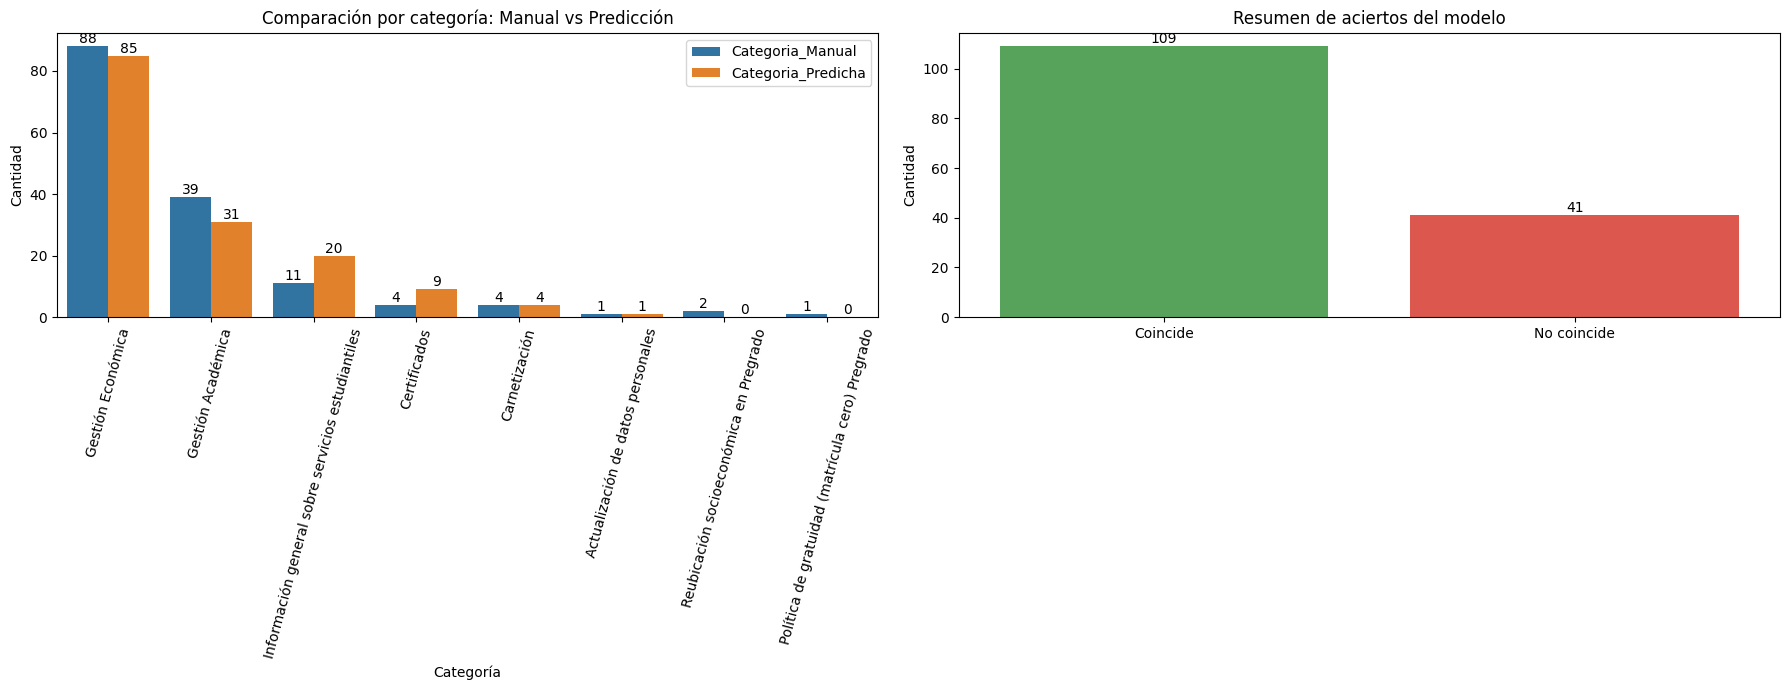

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata

# Reusar las columnas detectadas en la celda anterior para evitar KeyError
if "col_manual" not in globals() or "col_pred" not in globals():
    raise ValueError("No se encontraron 'col_manual' y 'col_pred'. Ejecuta primero la celda de validación.")

# Variantes frecuentes observadas en los archivos de validación
MAPEO_VARIANTES = {
    "gestion academica": "Gestión Académica",
    "gestion economica": "Gestión Económica",
    "carnetizacion": "Carnetización",
    "actualizacion de datos personales": "Actualización de datos personales",
    "reubicacion socioeconomica en pregrado": "Reubicación socioeconómica en Pregrado",
    "politica de gratuidad": "Política de gratuidad (matrícula cero) Pregrado",
    "politica de gratuidad matricula cero pregrado": "Política de gratuidad (matrícula cero) Pregrado",
    "informacion general sobre servicios estudiantiles": "Información general sobre servicios estudiantiles",
}

def normalizar_categoria(categoria: str) -> str:
    txt = str(categoria).strip()
    txt = unicodedata.normalize("NFKD", txt).encode("ascii", "ignore").decode("ascii")
    txt = " ".join(txt.lower().split())
    return MAPEO_VARIANTES.get(txt, str(categoria).strip())

manual_norm = df_predi[col_manual].astype(str).map(normalizar_categoria)
pred_norm = df_predi[col_pred].astype(str).map(normalizar_categoria)

comparacion_categorias = pd.DataFrame(
    {
        "Categoria_Manual": manual_norm.value_counts(),
        "Categoria_Predicha": pred_norm.value_counts(),
    }
).fillna(0)

comparacion_categorias["total"] = (
    comparacion_categorias["Categoria_Manual"] + comparacion_categorias["Categoria_Predicha"]
)
comparacion_categorias = comparacion_categorias.sort_values("total", ascending=False).drop(columns="total")

comparacion_plot = comparacion_categorias.reset_index().rename(columns={"index": "Categoria"})
comparacion_plot = comparacion_plot.melt(
    id_vars="Categoria",
    var_name="Tipo",
    value_name="Cantidad"
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=comparacion_plot,
    x="Categoria",
    y="Cantidad",
    hue="Tipo",
    ax=axes[0]
)
axes[0].set_title("Comparación por categoría: Manual vs Predicción")
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=75)
axes[0].legend(title="")

coincide_norm = manual_norm.str.lower() == pred_norm.str.lower()
resumen_coincidencia = coincide_norm.value_counts().rename({
    True: "Coincide",
    False: "No coincide"
}).reset_index()
resumen_coincidencia.columns = ["Resultado", "Cantidad"]

sns.barplot(
    data=resumen_coincidencia,
    x="Resultado",
    y="Cantidad",
    palette=["#4CAF50", "#F44336"],
    ax=axes[1]
)
axes[1].set_title("Resumen de aciertos del modelo")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cantidad")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

# Validación con varias muestras

In [21]:
df

,Categoria,Resuelta,Consulta,Categoria_Mapeada,Consulta_Procesada
0,Carnetización,No,Ayuda no se como inscribir asignaturas y nadie...,Carnetización,ayuda inscribir asignatura explicar
1,Calendario académico,No,Donde puedo ver el calendario académico?,Calendario académico,calendario
2,Carnetización,No,Quiero mi carné nuevo,Carnetización,carné
3,Calendario académico,No,Puedo tener mi recibo antes,Calendario académico,recibo
4,Calendario académico,No,No tengo cita para inscribir asignaturas.,Calendario académico,citar inscribir asignatura
...,...,...,...,...,...
35145,Actualización de datos personales,No,"Necesito cambiar una información personal, mi ...",Actualización de datos personales,cambiar información personal nombre lugar proc...
35146,Gestión Económica - Inconsistencias sobre recibo,No,Solicito que se ajusten los valores de recibo ...,Gestión Económica,ajustar valor recibo pago correspondiente dere...
35147,Presentación de examen admisión siendo estudiante,No,Quiero saber si puedo presentar el examen de a...,Información general sobre servicios estudiantiles,presentar examen admisión vinculado historia a...
35148,Desbloquear solicitud,No,Mi consulta va dirigida a que amablemente me ...,Información general sobre servicios estudiantiles,consulta dirigido cerrar manualmente cancelami...


In [22]:
# Sacar 5 muestras diferentes de 150 registros cada una
muestra1 = df.sample(n=150, random_state=1)
muestra2 = df.sample(n=150, random_state=2)
muestra3 = df.sample(n=150, random_state=3)
muestra4 = df.sample(n=150, random_state=4)
muestra5 = df.sample(n=150, random_state=5)

# Verificar el tamaño de cada muestra
print("Tamaño de muestra 1:", len(muestra1))
print("Tamaño de muestra 2:", len(muestra2))
print("Tamaño de muestra 3:", len(muestra3))
print("Tamaño de muestra 4:", len(muestra4))
print("Tamaño de muestra 5:", len(muestra5))


Tamaño de muestra 1: 150
Tamaño de muestra 2: 150
Tamaño de muestra 3: 150
Tamaño de muestra 4: 150
Tamaño de muestra 5: 150


In [31]:
# Guardar las muestras en un archivo Excel con cada muestra en una hoja diferente
import pandas as pd

# Agrupar las muestras creadas previamente
muestras = [muestra1, muestra2, muestra3, muestra4, muestra5]

# Crear un nuevo archivo Excel
excel_file = "muestras.xlsx"
writer = pd.ExcelWriter(excel_file, engine="openpyxl")

# Guardar cada muestra en una hoja diferente
for i, muestra in enumerate(muestras, 1):
    df_1 = pd.DataFrame(muestra)
    df_1.to_excel(writer, sheet_name=f"Muestra_{i}", index=False)

# Guardar el archivo Excel
writer.close()
print(f"Las muestras se han guardado en '{excel_file}' en hojas separadas.")

Las muestras se han guardado en 'muestras.xlsx' en hojas separadas.
